# A tour of the physics operators

In [19]:
%%capture
# Install deepinv
!pip install git+https://github.com/deepinv/deepinv.git

In [20]:
import torch
import deepinv as dinv
from deepinv.utils import load_url_image, get_image_url
import matplotlib.pyplot as plt

torch.manual_seed(0)

In [21]:
device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"

The image available with the get_image_url function are available hosted here https://huggingface.co/datasets/deepinv/images/tree/main

In [22]:
url = get_image_url("cameraman.png")
x_gray = load_url_image(url=url, img_size=512, grayscale=True, device=device)

In [23]:
def get_info(x):
    print('The image has size', x.size())

    print('The image is a cuda tensor', x.is_cuda)

    print('The image has min and max:', x.min().item(), x_gray.max().item())

    print('\n')

get_info(x_gray)

The image has size torch.Size([1, 1, 512, 512])
The image is a cuda tensor False
The image has min and max: 0.0 1.0




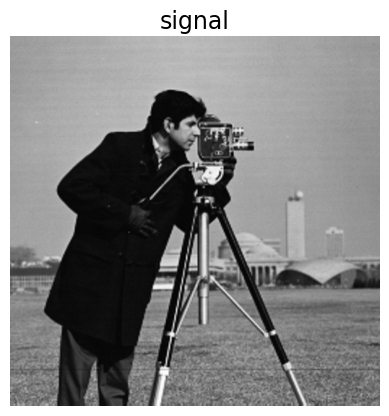

In [24]:
plt.imshow(x_gray[0,0,:,:].cpu(), cmap='gray')
plt.title('signal')
plt.axis('off')
plt.show()

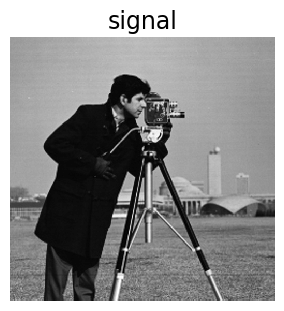

In [25]:
dinv.utils.plot([x_gray], ["signal"], figsize=(3,3))

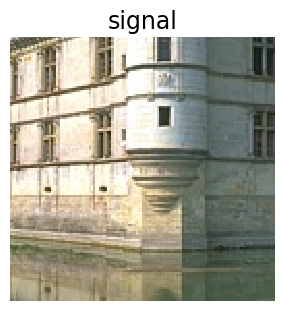

In [26]:
url = get_image_url("CBSD_0010.png")

img_size = 128

x_color = load_url_image(url, img_size=img_size, grayscale=False, device=device)

dinv.utils.plot([x_color], ["signal"], figsize=(3,3))

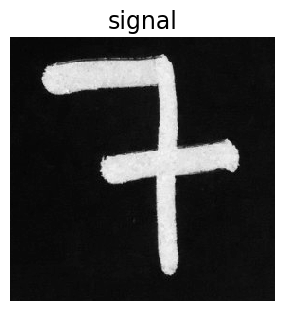

In [27]:
url = ("https://i.sstatic.net/fyPhv.jpg")

x_mnist = load_url_image(url=url, img_size=280, grayscale=True, device=device)
x_mnist = 1 - x_mnist

dinv.utils.plot([x_mnist], ["signal"], figsize=(3,3))

In [28]:
examples = [x_color, x_gray, x_mnist]

for x in examples:
    get_info(x)

The image has size torch.Size([1, 3, 128, 128])
The image is a cuda tensor False
The image has min and max: 0.01568627543747425 1.0


The image has size torch.Size([1, 1, 512, 512])
The image is a cuda tensor False
The image has min and max: 0.0 1.0


The image has size torch.Size([1, 1, 280, 280])
The image is a cuda tensor False
The image has min and max: 0.1921568512916565 1.0




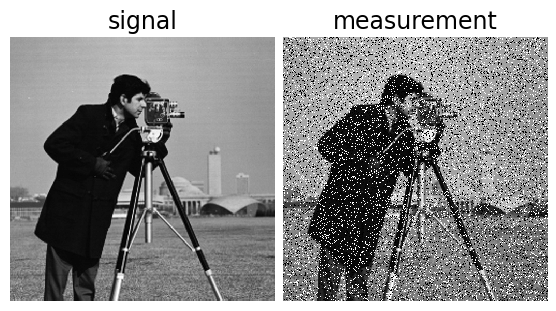

In [29]:
physics = dinv.physics.Denoising(dinv.physics.SaltPepperNoise(p=0.1, s=0.1))

y = physics(x_gray)

dinv.utils.plot([x_gray, y], titles=["signal", "measurement"], figsize=(6,3))

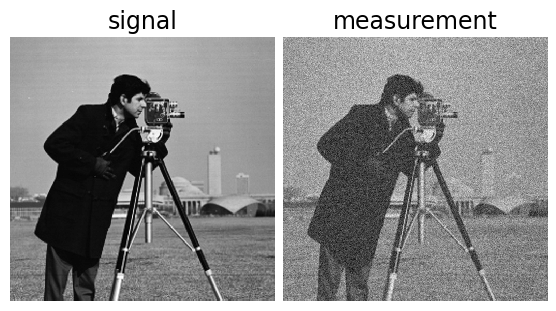

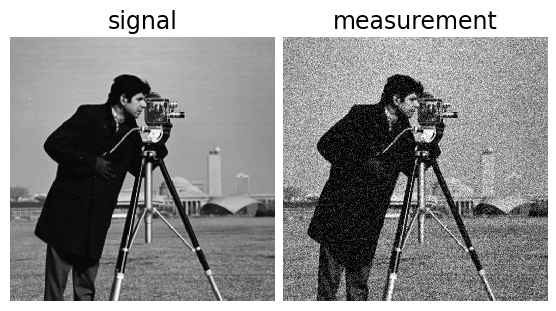

In [30]:
physics = dinv.physics.Denoising(dinv.physics.GaussianNoise(sigma=0.1))

y = physics(x_gray)

dinv.utils.plot([x_gray, y], titles=["signal", "measurement"], figsize=(6,3))
dinv.utils.plot([x_gray, y], titles=["signal", "measurement"], rescale_mode='clip', figsize=(6,3))

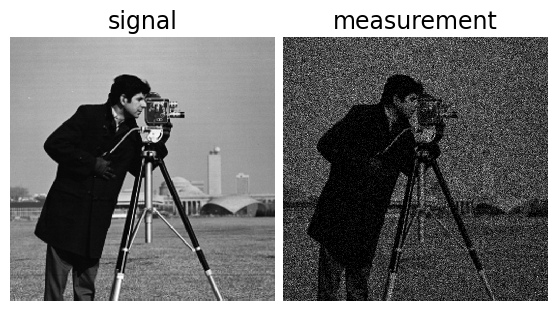

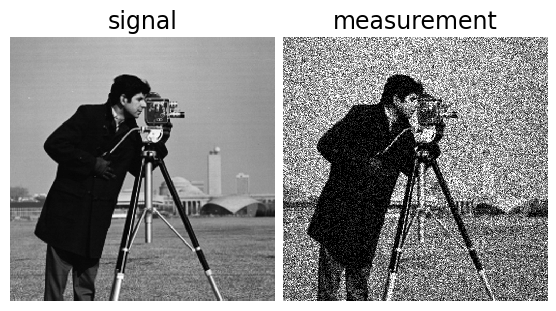

In [31]:
physics = dinv.physics.Denoising(dinv.physics.PoissonNoise(gain=0.1))

y = physics(x_gray)

dinv.utils.plot([x_gray, y], titles=["signal", "measurement"], figsize=(6,3))
dinv.utils.plot([x_gray, y], titles=["signal", "measurement"], rescale_mode='clip', figsize=(6,3))

In [32]:
noise_model=dinv.physics.GaussianNoise(sigma=0.01)

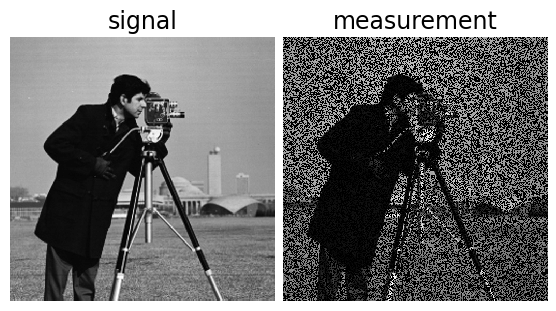

In [33]:
physics = dinv.physics.Inpainting((1, 512, 512), mask = 0.5, \
                                    noise_model=noise_model,\
                                    device = device)

y = physics(x_gray)
dinv.utils.plot([x_gray, y], titles=["signal", "measurement"], rescale_mode='clip', figsize=(6,3))

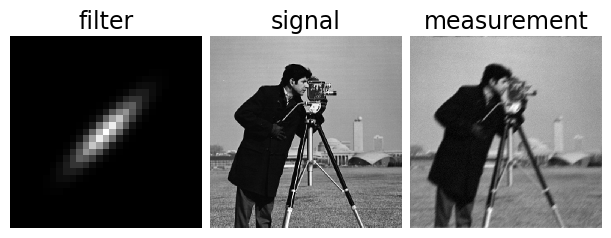

In [34]:
filter = dinv.physics.blur.gaussian_blur(sigma=(1, 4), angle=45)

physics = dinv.physics.Blur(filter,padding='circular', \
                            noise_model=noise_model,\
                            device=device)

y = physics(x_gray)
dinv.utils.plot([filter, x_gray, y], ["filter","signal", "measurement"], rescale_mode='clip', figsize=(6,3))

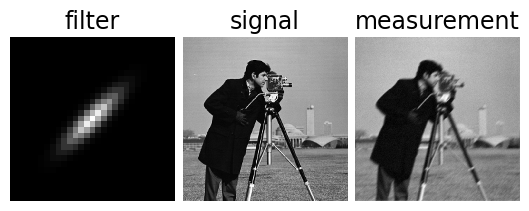

In [35]:
physics = dinv.physics.BlurFFT(filter=filter, img_size=(1, 512, 512),\
                            noise_model=noise_model,\
                                device=device)

y = physics(x_gray)
dinv.utils.plot([filter, x_gray, y], ["filter","signal", "measurement"], rescale_mode='clip')

In [36]:
angles = torch.linspace(0,179,steps=60)

physics = dinv.physics.Tomography(angles=angles, img_width=200, circle=False, noise_model=noise_model, device=device)

y = physics(x_mnist)
dinv.utils.plot(
    [x, (y - y.min()) / y.max(), physics.A_dagger(y)],
    titles=["signal", "sinogram", "filtered backprojection"],
)

ValueError: Input image size torch.Size([280, 280]) does not match the operator image size (200, 200).

In [ ]:
filter = dinv.physics.blur.gaussian_blur(sigma=(2, 2), angle=0)
physics = dinv.physics.Downsampling(img_size=(1, 512, 512), filter=filter, factor=4,\
                                    noise_model=noise_model, device=device)


y = physics(x_gray)

# plot results
dinv.utils.plot([x_gray, y, physics.A_dagger(y)], titles=["signal", "measurement", "linear invese"], figsize=(6,3))

print(x_gray.size())
print(y.size())

In [ ]:
physics = dinv.physics.Decolorize(device=device)

y = physics(x_color)

# plot results
dinv.utils.plot([x_color, y, physics.A_dagger(y)], titles=["signal", "measurement", "linear inverse"])